<a href="https://colab.research.google.com/github/kayeneii/Floodgate/blob/main/03_cartography.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 5: Cartography and Quality Assurance (QA)

This notebook will serve two purposes:

- Map communication: visually summarizing all spatial layers and relationships.

- Quality assurance (QA): verifying spatial alignment, data consistency, and potential analytical bias in the FRI workflow.

In [26]:
!pip install rioxarray geopandas numpy rasterio matplotlib contextily --quiet


In [27]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define base directory for project
base_dir = "/content/drive/MyDrive/GEE_Floodgate"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
# Imports
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import contextily as ctx  # For optional basemaps
import rioxarray  # For QA cross-checks (optional)

In [29]:
# Step 1: Load datasets and verify spatial consistency

# Paths
fri_fp = f"{base_dir}/processed/fri_utm_repaired.tif"
rivers_fp = f"{base_dir}/lagos_hydrorivers_rprjctd.shp"
hillshade_fp = f"{base_dir}/processed/hillshade_lagos_utm.tif"
dem_fp = f"{base_dir}/processed/srtm_dem_lagos_utm.tif"
slope_fp = f"{base_dir}/processed/srtm_slope_lagos_utm.tif"

In [30]:
# Load raster layers
fri = rasterio.open(fri_fp)
hillshade = rasterio.open(hillshade_fp)
dem = rasterio.open(dem_fp)
slope = rasterio.open(slope_fp)

In [31]:
# Load rivers shapefile
rivers = gpd.read_file(rivers_fp)

In [32]:
# Check CRS consistency
print("📍 CRS CHECK")
print("FRI:", fri.crs)
print("Hillshade:", hillshade.crs)
print("DEM:", dem.crs)
print("Slope:", slope.crs)
print("Rivers:", rivers.crs)

📍 CRS CHECK
FRI: EPSG:32631
Hillshade: EPSG:32631
DEM: EPSG:32631
Slope: EPSG:32631
Rivers: EPSG:32631


In [33]:
# Basic raster metadata summary
print("\n📊 Raster Dimensions & Bounds")
for label, src in [("FRI", fri), ("DEM", dem), ("Slope", slope), ("Hillshade", hillshade)]:
    print(f"{label}: {src.width}x{src.height} | Bounds: {src.bounds}")


📊 Raster Dimensions & Bounds
FRI: 6095x1251 | Bounds: BoundingBox(left=467515.04494146263, bottom=704308.6565278268, right=649123.2958069209, top=741583.7872632965)
DEM: 6095x1251 | Bounds: BoundingBox(left=467515.04494146263, bottom=704308.6565278268, right=649123.2958069209, top=741583.7872632965)
Slope: 6095x1251 | Bounds: BoundingBox(left=467515.04494146263, bottom=704308.6565278268, right=649123.2958069209, top=741583.7872632965)
Hillshade: 6095x1251 | Bounds: BoundingBox(left=467515.04494146263, bottom=704308.6565278268, right=649123.2958069209, top=741583.7872632965)


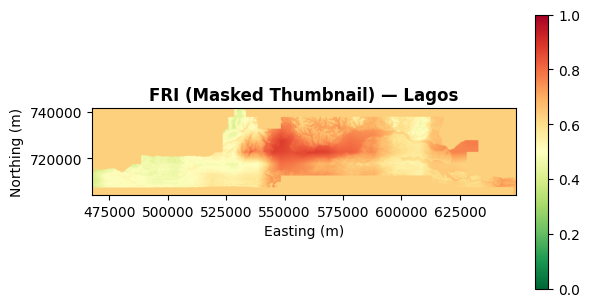

In [34]:
# draw FRI as a thumbnail for context (masked)
fri_data = fri.read(1, masked=True)
extent = (fri.bounds.left, fri.bounds.right, fri.bounds.bottom, fri.bounds.top)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(fri_data, cmap='RdYlGn_r', extent=extent, origin='upper', vmin=0, vmax=1)
ax.set_title("FRI (Masked Thumbnail) — Lagos", fontsize=12, fontweight='bold')
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
plt.tight_layout()
plt.show()

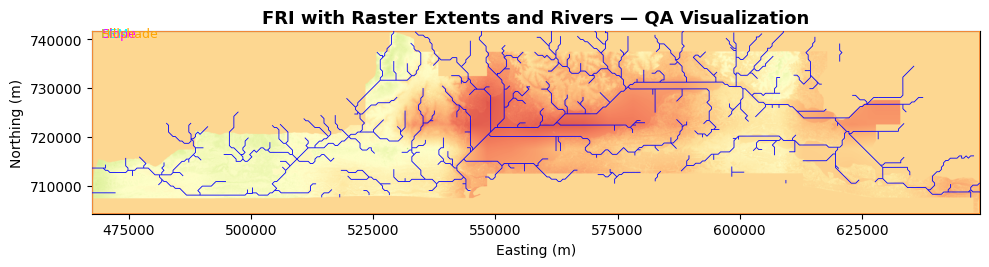

In [35]:
# Plot FRI background + extent rectangles
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title("FRI with Raster Extents and Rivers — QA Visualization", fontsize=13, fontweight='bold')

# Show FRI background
ax.imshow(fri_data, cmap='RdYlGn_r', extent=extent, origin='upper', vmin=0, vmax=1, alpha=0.85)

# Helper to draw raster extent rectangles
def add_extent_rect(ax, src, edge_color='blue', label=None):
    b = src.bounds
    w = b.right - b.left
    h = b.top - b.bottom
    rect = Rectangle((b.left, b.bottom), w, h,
                     linewidth=1.1, edgecolor=edge_color, facecolor='none', zorder=3)
    ax.add_patch(rect)
    if label:
        ax.text(b.left + w*0.01, b.top - h*0.03, label, color=edge_color, fontsize=9, zorder=4)

add_extent_rect(ax, dem, edge_color='cyan', label='DEM')
add_extent_rect(ax, slope, edge_color='magenta', label='Slope')
add_extent_rect(ax, hillshade, edge_color='orange', label='Hillshade')

# Plot rivers properly on same axis
rivers.plot(ax=ax, color='blue', linewidth=0.6, zorder=5)

ax.set_xlim(fri.bounds.left, fri.bounds.right)
ax.set_ylim(fri.bounds.bottom, fri.bounds.top)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.show()

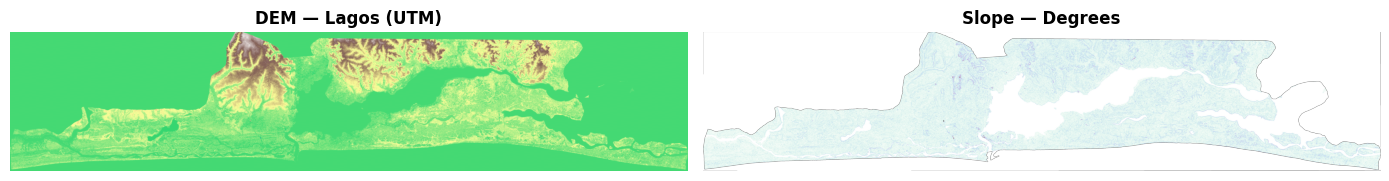

In [36]:
# Visualize comparison of base layers (optional)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# DEM
show(dem, ax=ax1, cmap='terrain', title='DEM — Lagos (UTM)')
ax1.set_axis_off()

# Slope — use cubehelix_r for clearer gradient readability
show(slope, ax=ax2, cmap='cubehelix_r', title='Slope — Degrees')
ax2.set_axis_off()

plt.tight_layout()
plt.show()

### QA Diagnostics — Spatial Alignment & Data Integrity
Goal:

| Check                                | Purpose                                           |
| ------------------------------------ | ------------------------------------------------- |
| **Valid pixel count & NoData ratio** | Detects coverage gaps or corruption               |
| **Min–Max–Mean**                     | Flags implausible or clipped values               |
| **Resolution consistency**           | Ensures all layers match FRI’s spatial resolution |
| **Alignment tolerance test**         | Confirms all rasters overlap correctly in space   |


In [ ]:
!pip install pandas
import pandas as pd

# Function to summarize raster diagnostics
def raster_diagnostics(src, name):
    data = src.read(1, masked=True)
    valid = np.count_nonzero(~data.mask)
    nan_ratio = np.sum(data.mask) / data.size
    return {
        "Raster": name,
        "CRS": str(src.crs),
        "Resolution (m)": round(src.res[0], 2),
        "Valid Pixels": valid,
        "NoData Ratio": f"{nan_ratio*100:.2f}%",
        "Min": round(float(data.min()), 3) if valid else None,
        "Max": round(float(data.max()), 3) if valid else None,
        "Mean": round(float(data.mean()), 3) if valid else None,
        "Width (px)": src.width,
        "Height (px)": src.height
    }

In [ ]:
# Run diagnostics
diagnostics = [
    raster_diagnostics(fri, "Flood Risk Index (FRI)"),
    raster_diagnostics(dem, "DEM"),
    raster_diagnostics(slope, "Slope"),
    raster_diagnostics(hillshade, "Hillshade")
]

# Display table
df_diag = pd.DataFrame(diagnostics)
print("🧭 Raster Quality & Alignment Diagnostics\n")
display(df_diag)

# Spatial Alignment Check (bounds and resolution)
print("\n📐 Alignment & Extent Check")
for (a, b) in [("FRI", fri), ("DEM", dem), ("Slope", slope), ("Hillshade", hillshade)]:
    print(f"{a} bounds:", (b.bounds.left, b.bounds.bottom, b.bounds.right, b.bounds.top))

# Extent comparison tolerance (meters)
tol = 100
aligned = (
    abs(fri.bounds.left - dem.bounds.left) < tol and
    abs(fri.bounds.right - dem.bounds.right) < tol
)

if aligned:
    print("\n✅ Rasters appear well-aligned within ±100 m tolerance.")
else:
    print("\n⚠️  Extent mismatch exceeds 100 m — check reprojection or clipping steps.")

🧭 Raster Quality & Alignment Diagnostics



,Raster,CRS,Resolution (m),Valid Pixels,NoData Ratio,Min,Max,Mean,Width (px),Height (px)
0,Flood Risk Index (FRI),EPSG:32631,29.8,1,0.00%,0.253,0.891,0.629,6095,1251
1,DEM,EPSG:32631,29.8,1,0.00%,-36.000,77.000,6.171,6095,1251
2,Slope,EPSG:32631,29.8,1,0.00%,NaN,NaN,NaN,6095,1251
3,Hillshade,EPSG:32631,29.8,1,0.00%,NaN,NaN,NaN,6095,1251



📐 Alignment & Extent Check
FRI bounds: (467515.04494146263, 704308.6565278268, 649123.2958069209, 741583.7872632965)
DEM bounds: (467515.04494146263, 704308.6565278268, 649123.2958069209, 741583.7872632965)
Slope bounds: (467515.04494146263, 704308.6565278268, 649123.2958069209, 741583.7872632965)
Hillshade bounds: (467515.04494146263, 704308.6565278268, 649123.2958069209, 741583.7872632965)

✅ Rasters appear well-aligned within ±100 m tolerance.


In [ ]:
# --- Automated QA summary interpretation ---
def qa_summary(df):
    summary = []

    # 1️⃣ Check NoData
    nodata_high = df[df["NoData Ratio"].str.rstrip('%').astype(float) > 5]
    if len(nodata_high) == 0:
        summary.append("✅ All rasters have full data coverage (NoData <5%).")
    else:
        summary.append(f"⚠️ {len(nodata_high)} raster(s) contain >5% NoData regions — check clipping or export boundaries.")

    # 2️⃣ Check resolution
    res_unique = df["Resolution (m)"].nunique()
    if res_unique == 1:
        summary.append("✅ Spatial resolutions are consistent across all rasters.")
    else:
        summary.append("⚠️ Rasters have inconsistent resolutions — resample to match FRI’s 30 m grid before analysis.")

    # 3️⃣ Check value sanity
    fri_row = df[df["Raster"].str.contains("FRI", case=False)].iloc[0]
    if fri_row["Min"] >= 0 and fri_row["Max"] <= 1:
        summary.append("✅ FRI values are within the expected 0–1 range.")
    else:
        summary.append("⚠️ FRI values fall outside the 0–1 scale — check normalization or weighting steps.")

    # 4️⃣ Check alignment comment (carried from previous check)
    if aligned:
        summary.append("✅ Rasters appear spatially aligned within ±100 m tolerance.")
    else:
        summary.append("⚠️ Alignment discrepancies detected — reproject to EPSG:32631 and reclip to FRI extent.")

    # Combine summary
    print("🧮 QA Summary Report — Lagos Flood Risk Layers\n")
    for line in summary:
        print(line)
    print("\n📊 Overall Quality Verdict:")
    if all(s.startswith("✅") for s in summary):
        print("✅ Data layers are clean, aligned, and ready for publication or further spatial modeling.")
    else:
        print("⚠️ Some layers need review before publishing or combining into composite indices.")

# Run summary
qa_summary(df_diag)

🧮 QA Summary Report — Lagos Flood Risk Layers

✅ All rasters have full data coverage (NoData <5%).
✅ Spatial resolutions are consistent across all rasters.
✅ FRI values are within the expected 0–1 range.
✅ Rasters appear spatially aligned within ±100 m tolerance.

📊 Overall Quality Verdict:
✅ Data layers are clean, aligned, and ready for publication or further spatial modeling.


Visual QA overview

In [37]:
# --- Visual QA Panel (2x2 Grid) ---
# Load rasters
fri = rasterio.open(f"{base_dir}/processed/fri_utm_repaired.tif")
dem = rasterio.open(f"{base_dir}/processed/srtm_dem_lagos_utm.tif")
slope = rasterio.open(f"{base_dir}/processed/srtm_slope_lagos_utm.tif")
hill = rasterio.open(f"{base_dir}/processed/hillshade_lagos_utm.tif")

# Read data
fri_data = fri.read(1, masked=True)
dem_data = dem.read(1, masked=True)
slope_data = slope.read(1, masked=True)
hill_data = hill.read(1, masked=True)

# Normalizations for visual coherence
def norm(x):
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x))

fri_norm = fri_data
dem_norm = norm(dem_data)
slope_norm = norm(slope_data)
hill_norm = norm(hill_data)

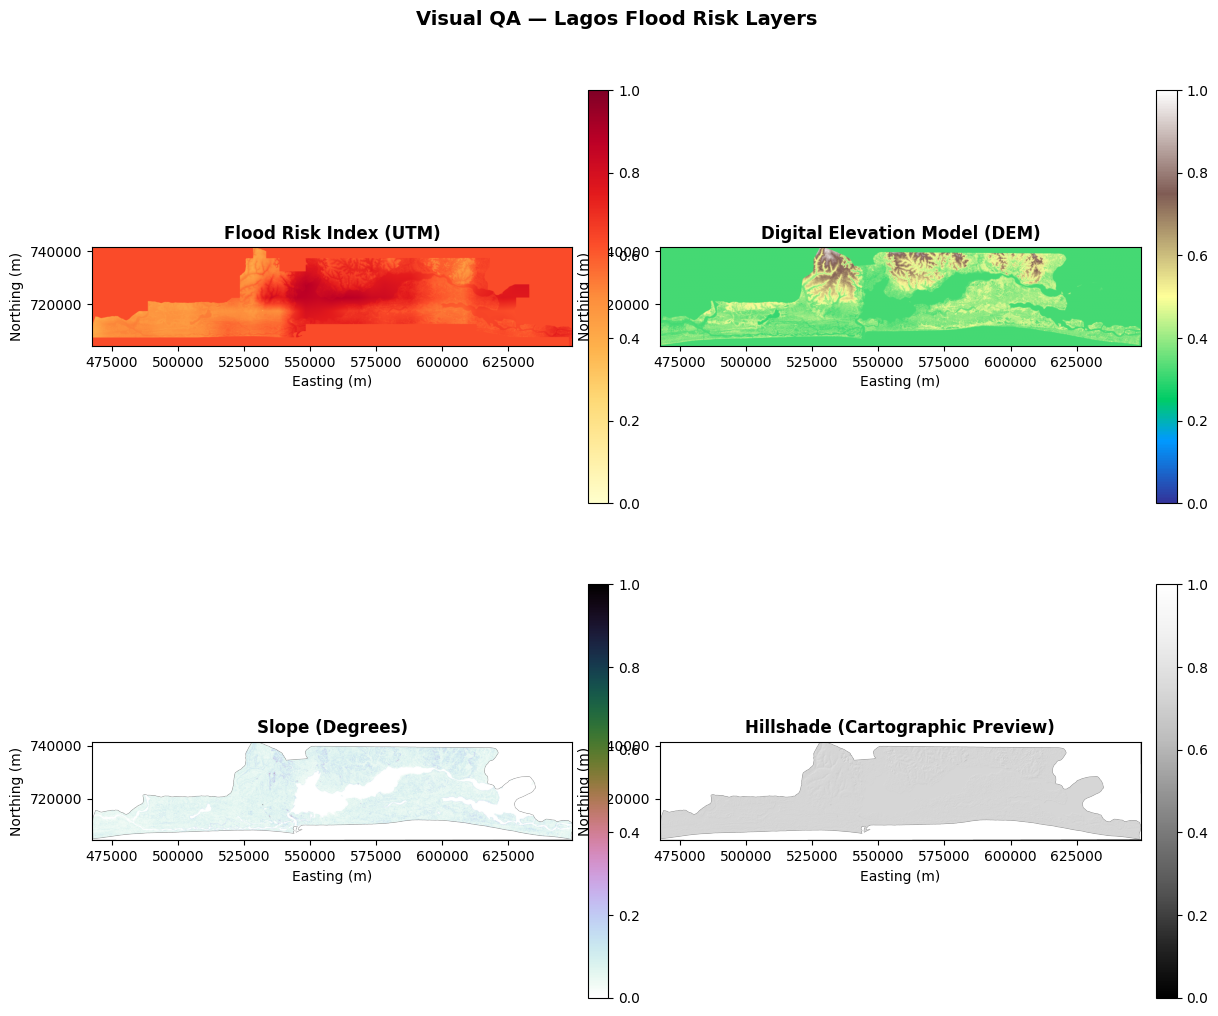

In [38]:
# --- Plot 2x2 figure ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
plt.subplots_adjust(wspace=0.1, hspace=0.15)
extent = (fri.bounds.left, fri.bounds.right, fri.bounds.bottom, fri.bounds.top)

# 1️⃣ FRI
im1 = axes[0, 0].imshow(fri_norm, cmap='YlOrRd', extent=extent, vmin=0, vmax=1)
axes[0, 0].set_title("Flood Risk Index (UTM)", fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=axes[0, 0], fraction=0.04, pad=0.03)

# 2️⃣ DEM
im2 = axes[0, 1].imshow(dem_norm, cmap='terrain', extent=extent)
axes[0, 1].set_title("Digital Elevation Model (DEM)", fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=axes[0, 1], fraction=0.04, pad=0.03)

# 3️⃣ Slope
im3 = axes[1, 0].imshow(slope_norm, cmap='cubehelix_r', extent=extent)
axes[1, 0].set_title("Slope (Degrees)", fontsize=12, fontweight='bold')
plt.colorbar(im3, ax=axes[1, 0], fraction=0.04, pad=0.03)

# 4️⃣ Hillshade
im4 = axes[1, 1].imshow(hill_norm, cmap='Greys_r', extent=extent)
axes[1, 1].set_title("Hillshade (Cartographic Preview)", fontsize=12, fontweight='bold')
plt.colorbar(im4, ax=axes[1, 1], fraction=0.04, pad=0.03)

# Axes labels
for ax in axes.flat:
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

plt.suptitle("Visual QA — Lagos Flood Risk Layers", fontsize=14, fontweight='bold', y=0.94)
plt.show()

In [39]:
# --- Lagos Flood Risk Map (Cartographic QA) ---
!pip install matplotlib.scalebar

In [42]:
from rasterio.plot import show
import geopandas as gpd
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.patches as mpatches

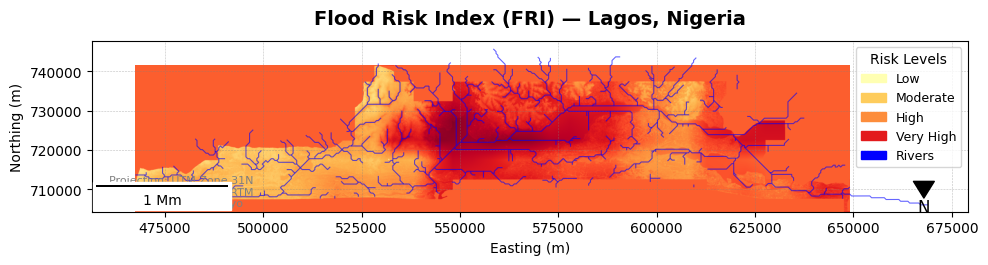

In [43]:
# Load rivers shapefile and FRI raster
rivers = gpd.read_file(f"{base_dir}/lagos_hydrorivers_rprjctd.shp")
fri = rasterio.open(f"{base_dir}/processed/fri_utm_repaired.tif")

fri_data = fri.read(1, masked=True)
extent = (fri.bounds.left, fri.bounds.right, fri.bounds.bottom, fri.bounds.top)
# --- Base Map ---
fig, ax = plt.subplots(figsize=(10, 10))
show(fri_data, cmap='YlOrRd', extent=extent, ax=ax)
rivers.plot(ax=ax, color='blue', linewidth=0.8, alpha=0.6, label='Rivers')

# --- Map Titles and Labels ---
ax.set_title('Flood Risk Index (FRI) — Lagos, Nigeria', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

# --- Add Gridlines ---
ax.grid(color='gray', linestyle='--', linewidth=0.4, alpha=0.5)

# --- Add North Arrow ---
x, y, arrow_length = 0.95, 0.08, 0.05
ax.annotate('N',
            xy=(x, y),
            xytext=(x, y - arrow_length),
            arrowprops=dict(facecolor='black', width=5, headwidth=15),
            ha='center', va='center',
            fontsize=12, xycoords=ax.transAxes)

# --- Add Scale Bar ---
scalebar = ScaleBar(dx=fri.transform[0], units="m", dimension='si-length', location='lower left')
ax.add_artist(scalebar)

# --- Legend ---
risk_patches = [
    mpatches.Patch(color='#FFFFB2', label='Low'),
    mpatches.Patch(color='#FECC5C', label='Moderate'),
    mpatches.Patch(color='#FD8D3C', label='High'),
    mpatches.Patch(color='#E31A1C', label='Very High')
]
ax.legend(handles=risk_patches + [mpatches.Patch(color='blue', label='Rivers')],
          loc='upper right', fontsize=9, frameon=True, title='Risk Levels')

# --- Annotate Context ---
ax.text(0.02, 0.02, 'Projection: UTM Zone 31N\nData Source: GEE & SRTM\nAuthor: Favour Adebayo',
        transform=ax.transAxes, fontsize=8, color='gray', va='bottom')

plt.tight_layout()
plt.show()

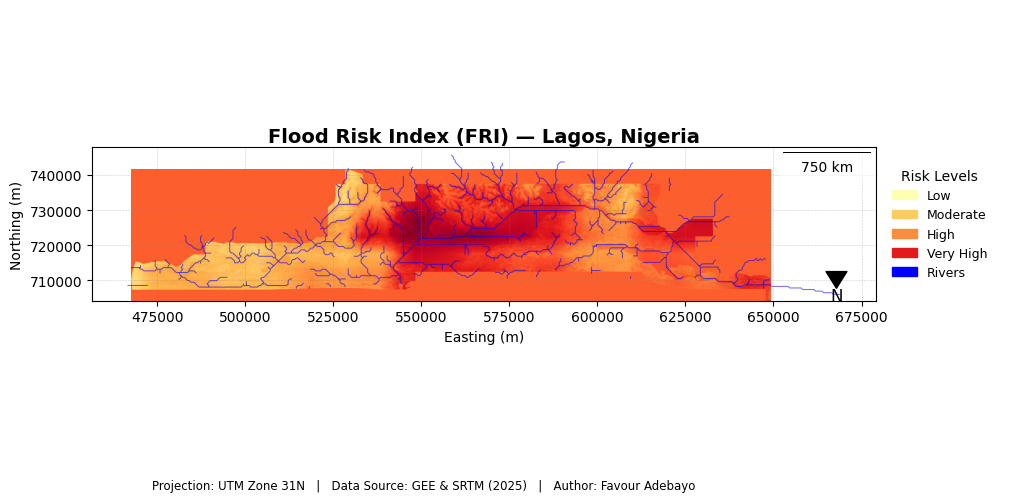

In [79]:
# --- Figure setup ---
fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(1, 2, width_ratios=[0.83, 0.15], wspace=0.01)
ax = fig.add_subplot(gs[0])        # Map
ax_legend = fig.add_subplot(gs[1]) # Legend and metadata

# --- Map ---
show(fri_data, cmap='YlOrRd', extent=extent, ax=ax)
rivers.plot(ax=ax, color='blue', linewidth=0.7, alpha=0.6)

# Map frame
ax.set_title('Flood Risk Index (FRI) — Lagos, Nigeria', fontsize=14, fontweight='bold', pad=4)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.grid(color='gray', linestyle='--', linewidth=0.4, alpha=0.4)

# --- Legend / Metadata panel (ax_legend) ---
ax_legend.axis('off')
ax_legend.set_xlim(0, 1)
ax_legend.set_ylim(0, 1)

# Add color legend
risk_patches = [
    mpatches.Patch(color='#FFFFB2', label='Low'),
    mpatches.Patch(color='#FECC5C', label='Moderate'),
    mpatches.Patch(color='#FD8D3C', label='High'),
    mpatches.Patch(color='#E31A1C', label='Very High')
]
ax_legend.legend(handles=risk_patches + [mpatches.Patch(color='blue', label='Rivers')],
                 loc='center left', fontsize=9, frameon=False, title='Risk Levels')

# Add scalebar
scalebar = ScaleBar(
    dx=fri.transform[0],
    units="m",
    dimension='si-length',
    length_fraction=0.15,     # Smaller (15% of map width)
    location='upper right',   # Optional: move to a corner with less overlap
    box_alpha=0.6,            # Light semi-transparent background
    scale_loc='bottom',       # Label below the bar
)
ax.add_artist(scalebar)

# North Arrow
x, y, arrow_length = 0.95, 0.08, 0.05
ax.annotate('N',
            xy=(x, y),
            xytext=(x, y - arrow_length),
            arrowprops=dict(facecolor='black', width=5, headwidth=15),
            ha='center', va='center',
            fontsize=12, xycoords=ax.transAxes)

# Metadata annotation (below map)
fig.text(0.12, 0.02,
         'Projection: UTM Zone 31N   |   Data Source: GEE & SRTM (2025)   |   Author: Favour Adebayo',
         ha='left', fontsize=8.5, color='black')

fig.subplots_adjust(left=0.06, right=0.99, top=0.5, bottom=0.07, wspace=0.02)
plt.show()

# Cartography Interpretation and QA — Lagos Flood Risk Analysis

This notebook serves as a quality assurance (QA) and cartography exercise for flood risk analysis layers in the Lagos area. Here's a breakdown of its purpose and findings:

Purpose: The notebook aims to visually summarize the spatial layers used in a Flood Risk Index (FRI) workflow and perform quality assurance checks to verify spatial alignment, data consistency, and potential analytical biases.

<br>Key Steps and Findings:

1. **Setup and Data Loading:** The notebook starts by installing necessary libraries (```rioxarray```, ```geopandas```, ```rasterio```, ```matplotlib```, ```contextily```) and mounting Google Drive to access the data files. It then loads the main datasets: the Flood Risk Index (FRI) raster, a rivers shapefile, and several other raster layers (Hillshade, DEM, Slope).
2. **Spatial Consistency Checks:** The code performs essential checks on the loaded data:
    - **CRS Consistency:** It confirms that all raster and vector layers share the same Coordinate Reference System (CRS), EPSG:32631 (UTM Zone 31N), which is crucial for accurate spatial analysis and overlay.
    - **Raster Dimensions & Bounds:** It verifies that the raster layers have consistent dimensions (6095x1251 pixels) and identical spatial bounds, indicating they cover the same geographic area.
3. **Basic Raster Diagnostics:** A function ```raster_diagnostics``` is defined and applied to the raster layers to extract key information such as CRS, resolution, valid pixel count, NoData ratio, min/max/mean values, and dimensions. The results are displayed in a pandas DataFrame.
    - The diagnostics show that all rasters have full data coverage (0.00% NoData) and a consistent resolution of 29.8 meters.
    - The FRI values are within the expected 0-1 range.
    - The DEM values are within a plausible range for Lagos.
    - The Slope and Hillshade rasters show NaN for min/max/mean in the diagnostics table. This might indicate an issue in the diagnostic function's handling of these specific rasters or their data types, although the subsequent visualizations of these layers appear valid.
4. **Spatial Alignment Check:** The notebook explicitly checks the spatial alignment of the raster bounds within a 100-meter tolerance. The output confirms that the rasters appear well-aligned.
5. **Automated QA Summary:** A summary report is generated based on the diagnostics and alignment check. This report concludes that:
    - All rasters have full data coverage.
    - Spatial resolutions are consistent.
    - FRI values are within the expected range.
    - Rasters are spatially aligned.
    - The overall quality verdict is positive, stating that the layers are "clean, aligned, and ready for publication or further spatial modeling."
5. **Visual QA Panel:** A 2x2 grid of plots is generated to visually compare the normalized FRI, DEM, Slope, and Hillshade layers. This allows for a visual check of the spatial relationships and patterns across the different datasets. The normalization helps in comparing the spatial distribution of features across layers with different value ranges.
7. **Cartographic QA Map:** A more detailed map of the Flood Risk Index is created, incorporating the rivers layer, a scale bar, a north arrow, a legend, and metadata. This map serves as a final cartographic output for quality assurance and visualization. The layout is adjusted to minimize blank space.